# Outside data, and adding versus cutting

Notebooks 11 to 13 found that prices and volume alone do not say which way a market
goes next, and that timing when to hold cash did no better than holding a fixed
smaller share. Two things were left to try.

**Information that is not in the price.**

| data | what it is | where from | markets |
|---|---|---|---|
| positioning | how far large speculators lean long or short, weekly | US regulator (CFTC), public | gold, US stocks, Bitcoin |
| funding rate | what traders with borrowed money pay to stay long, every 8 hours | Binance, public | Bitcoin, Ether, Solana |
| buy-side volume | of each hour's volume, the share bought by the more eager side | Binance, public | the same three |

**A question from the person using RADAR:** when a holding falls, is it better to keep
adding on a schedule, or to sell before a gain turns into a loss and buy back later?

Three parts, each with rules and pass marks written down before running
(`docs/DECISIONS.md`, entries 066 and 067):

- **A.** Does crowded positioning say what comes next?
- **B.** Adding on schedule, against cutting at break-even, against waiting for dips.
- **C.** Do funding rates and buy-side volume let a model call the next day?

Rebuild with `uv run python backend/scripts/build_notebooks.py 14_outside_data_and_buying`
(reads `data/research/`; needs the `nlp` extra; minutes on a GPU).

In [1]:
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest, wilcoxon

from radar.analytics import buying, positioning
from radar.analytics import technical as ta
from radar.db.session import make_engine, session_scope
from radar.models import direction
from radar.pipelines import research
from radar.pipelines.signals import daily_close
from radar.providers import binance_public, cftc
from radar.signals import track
from radar.universe import get_universe

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 120)
engine, universe = make_engine(), get_universe()
NAMES = {"BTC/USD": "Bitcoin", "GLD": "Gold", "SPY": "US stocks"}

own = {}
with session_scope(engine) as session:
    for asset in universe.primary:
        close = daily_close(session, asset)
        close.index = pd.DatetimeIndex(close.index).tz_localize(None)
        own[asset.symbol] = close
CONTRACTS = {"GLD": cftc.GOLD, "SPY": cftc.SP500, "BTC/USD": cftc.BITCOIN}
with cftc.reader() as source:
    reports = research.load_positions(list(CONTRACTS.values()), source)
for symbol, contract in CONTRACTS.items():
    report = reports[contract.name]
    print(f"{NAMES[symbol]:10s} {contract.traders:16s} {len(report)} weekly reports, {report.index[0].date()} to {report.index[-1].date()}")

Gold       managed money    1060 weekly reports, 2006-06-13 to 2026-09-29
US stocks  leveraged funds  1060 weekly reports, 2006-06-13 to 2026-09-29
Bitcoin    leveraged funds  443 weekly reports, 2018-04-10 to 2026-09-29


## Part A. Positioning

Each week the regulator publishes how many contracts each kind of trader holds long
and short. The reading used here is **long minus short, as a share of all contracts**,
for the speculative group. It is "crowded long" when it is far above its own last
three years (1.5 spreads or more), and "crowded short" when far below.

A report describes a Tuesday and comes out on the Friday. Here it counts as known only
from the Monday after.

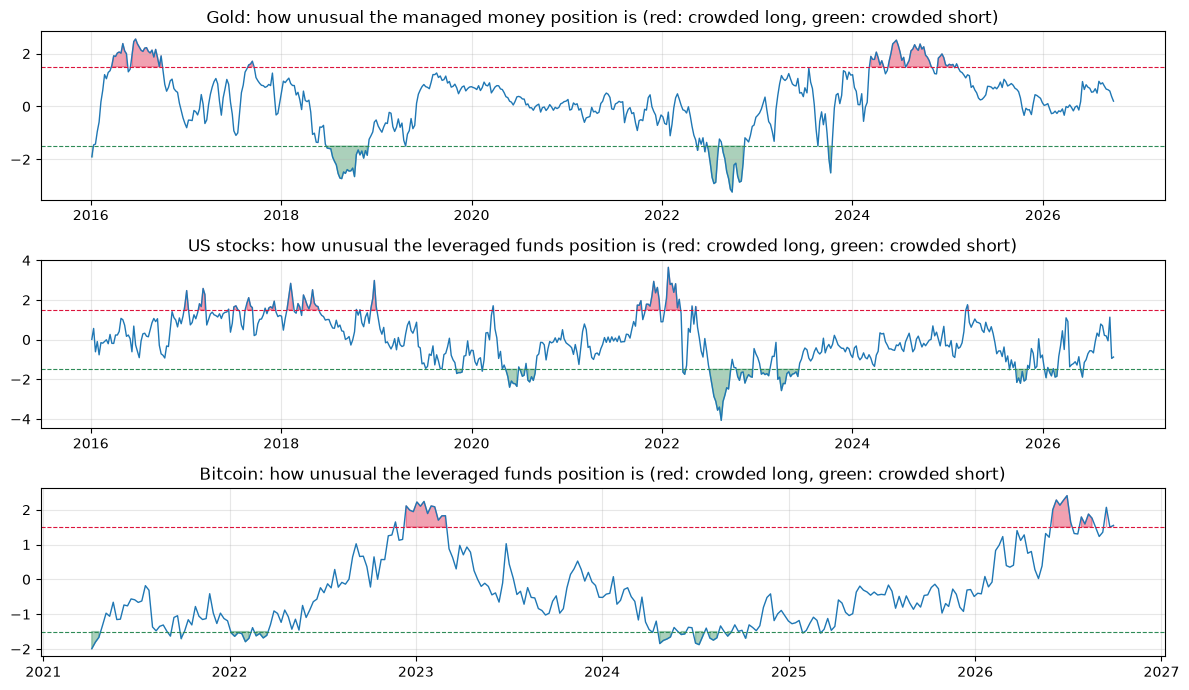

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
readings = {}
for ax, (symbol, contract) in zip(axes, CONTRACTS.items()):
    net = positioning.net_share(reports[contract.name])
    z = positioning.unusual(net, positioning.WEEKS)
    readings[symbol] = z
    shown = z[z.index >= own[symbol].index[0]]
    ax.plot(shown.index, shown, color="tab:blue", lw=1)
    ax.axhline(positioning.CROWDED, color="crimson", lw=0.8, ls="--")
    ax.axhline(-positioning.CROWDED, color="seagreen", lw=0.8, ls="--")
    ax.fill_between(shown.index, shown, positioning.CROWDED, where=shown >= positioning.CROWDED, color="crimson", alpha=0.4)
    ax.fill_between(shown.index, shown, -positioning.CROWDED, where=shown <= -positioning.CROWDED, color="seagreen", alpha=0.4)
    ax.set(title=f"{NAMES[symbol]}: how unusual the {contract.traders} position is (red: crowded long, green: crowded short)")
fig.tight_layout()

In [3]:
records = []
for symbol, z in readings.items():
    close = own[symbol]
    days = pd.DatetimeIndex(close.index)
    steps = 28 if symbol == "BTC/USD" else 20
    for name, flags in (("crowded long", z >= positioning.CROWDED), ("crowded short", z <= -positioning.CROWDED)):
        starts = pd.DatetimeIndex(positioning.run_starts(flags))
        known = positioning.known_from(starts, days)
        records.append(track.record("positioning", symbol, name, [d for d in known if not pd.isna(d)], close, [(steps, "4 weeks")]))
records = track.correct_family(records)
rows = []
for r in records:
    h = r.horizons[0]
    rows.append({"market": NAMES[r.symbol], "reading": r.variant, "separate runs": r.n,
                 "rose over 4 weeks %": None if h.signal.share_positive is None else h.signal.share_positive * 100,
                 "range low": None if h.signal.share_low is None else h.signal.share_low * 100,
                 "range high": None if h.signal.share_high is None else h.signal.share_high * 100,
                 "any day %": h.baseline.share_positive * 100, "direction": h.verdict, "size": h.size_verdict})
followed = pd.DataFrame(rows)
followed

,market,reading,separate runs,rose over 4 weeks %,range low,range high,any day %,direction,size
0,Gold,crowded long,12,75.000,46.769,91.106,57.154,not enough occurrences,not enough occurrences
1,Gold,crowded short,15,66.667,41.714,84.824,57.154,not enough occurrences,not enough occurrences
2,US stocks,crowded long,25,40.000,23.403,59.261,70.194,not enough occurrences,not enough occurrences
3,US stocks,crowded short,22,40.909,23.256,61.265,70.194,not enough occurrences,not enough occurrences
4,Bitcoin,crowded long,6,100.000,51.011,100.000,53.442,not enough occurrences,not enough occurrences
5,Bitcoin,crowded short,14,64.286,38.764,83.655,53.442,not enough occurrences,not enough occurrences


In [4]:
rows = []
for symbol, z in readings.items():
    close = own[symbol]
    daily = positioning.on_trading_days(z, pd.DatetimeIndex(close.index)).dropna()
    weight = positioning.hold_unless_crowded(daily)
    returns = close.pct_change().loc[weight.index]
    per_year = 365 if symbol == "BTC/USD" else 252
    rule = ta.backtest(returns, weight)
    share = weight.shift(1).reindex(rule.index).mean()
    fixed = ta.backtest(returns, pd.Series(share, index=weight.index))
    hold = ta.backtest(returns, pd.Series(1.0, index=weight.index))
    gap, p_value = ta.sharpe_difference(rule, fixed, per_year)
    rows.append({"market": NAMES[symbol], "days": len(rule), "days at half %": (weight < 1).mean() * 100,
                 "rule Sharpe": ta.sharpe(rule, per_year), "fixed share Sharpe": ta.sharpe(fixed, per_year), "holding Sharpe": ta.sharpe(hold, per_year),
                 "difference from fixed share": gap, "p": p_value,
                 "rule fall %": ta.deepest_fall(rule) * 100, "fixed share fall %": ta.deepest_fall(fixed) * 100})
position_rule = pd.DataFrame(rows)
passing = track.survivors([(i, 0, p) for i, p in enumerate(position_rule["p"])], 0.05)
position_rule["passes"] = [(i, 0) in passing and row["difference from fixed share"] > 0 and row["rule fall %"] >= row["fixed share fall %"] for i, row in position_rule.iterrows()]
position_rule

,market,days,days at half %,rule Sharpe,fixed share Sharpe,holding Sharpe,difference from fixed share,p,rule fall %,fixed share fall %,passes
0,Gold,2703,12.500,0.786,0.818,0.818,-0.032,0.464,-26.405,-24.861,False
1,US stocks,2703,11.428,0.911,0.895,0.895,0.015,0.741,-33.794,-32.117,False
2,Bitcoin,2003,8.483,0.284,0.393,0.393,-0.109,0.067,-76.673,-74.957,False


### What part A shows

**Too few cases to judge, in every market.** Counting each run of crowded weeks once,
ten years give between 6 and 25 runs per market and side. The written rule needs 30, so
the verdict everywhere is "not enough". That is the honest result for weekly data: it
simply does not happen often.

**As a rule for how much to hold, it did nothing.** Holding half while positioning was
crowded long did not beat a fixed share of the same size in any of the three markets,
and its deepest fall was slightly deeper in all three.

**One thing worth writing down, not acting on.** In US stocks the four weeks after a
crowded reading, on either side, ended higher about 40% of the time, against 70% for
any day, and with 25 and 22 runs the plausible range stops short of 70%. It is under
the 30 the rule requires, it was not predicted, and the same thing showing on both
sides is as likely to be a few bad stretches as a pattern. It needs a longer price
history than RADAR has before it can be tested.

## Part B. Adding on schedule, cutting at break-even, or waiting for dips

A person pays in the same amount every 21 trading days, in each of 27 markets (the 24
of notebook 13 and RADAR's own three). Three ways of behaving:

| behaviour | what the person does |
|---|---|
| **on schedule** | invests every payment the day it is made, whatever the price |
| **cut at break-even** | the same, but once the holding has been 5% ahead, sells everything the first day it is worth less than was paid for it; buys back on a new 20-day high |
| **wait for dips** | keeps payments in cash and invests it all when the price is 10% or more under its 60-day high |

Measured at the end as **value over total paid in** (1.50 means every 100 paid became
150), and by the **worst point**: the lowest that figure ever got.

In [5]:
GROUPS = {
    "stocks": ["QQQ", "IWM", "EFA", "EEM", "XLE", "XLF", "XLK", "XLV", "XLU", "VNQ", "SPY"],
    "bonds": ["TLT", "IEF", "LQD", "HYG"],
    "commodities": ["SLV", "USO", "DBC", "DBA", "GLD"],
    "crypto": ["ETH/USD", "SOL/USD", "LTC/USD", "LINK/USD", "AVAX/USD", "DOGE/USD", "BTC/USD"],
}
GROUP_OF = {symbol: group for group, symbols in GROUPS.items() for symbol in symbols}
COLOURS = {"stocks": "tab:blue", "bonds": "tab:green", "commodities": "goldenrod", "crypto": "tab:orange"}
fresh = research.load([s for s in GROUP_OF if s not in own], None, "")
closes = {s: (own[s] if s in own else fresh[s]["close"]).iloc[ta.WARM_UP :] for s in GROUP_OF}

rows, replays = [], {}
for symbol, close in closes.items():
    plain = buying.on_schedule(close)
    cut, cut_trades = buying.cut_at_break_even(close)
    dips, dip_trades = buying.wait_for_dips(close)
    results = {"schedule": buying.outcome(plain), "cut": buying.outcome(cut, cut_trades), "dips": buying.outcome(dips, dip_trades)}
    replays[symbol] = {"schedule": plain, "cut": cut, "dips": dips}
    row = {"market": symbol, "group": GROUP_OF[symbol], "payments": int(plain["paid"].iloc[-1])}
    for name, result in results.items():
        row[f"{name} end"], row[f"{name} worst %"] = result.end, result.worst * 100
        if name != "schedule":
            row[f"{name} in cash %"], row[f"{name} trades"] = result.cash_share * 100, result.trades
            row[f"{name} same cash end"] = buying.outcome(buying.on_schedule(close, cash_share=result.cash_share)).end
    rows.append(row)
paying = pd.DataFrame(rows).set_index("market")
paying[["group", "payments", "schedule end", "cut end", "dips end", "schedule worst %", "cut worst %", "dips worst %", "cut in cash %", "dips in cash %", "cut trades", "dips trades"]]

,group,payments,schedule end,cut end,dips end,schedule worst %,cut worst %,dips worst %,cut in cash %,dips in cash %,cut trades,dips trades
market,,,,,,,,,,,,
QQQ,stocks,117,2.988,2.641,2.899,-5.366,-3.515,-8.599,1.305,15.322,4,33
IWM,stocks,117,1.665,1.275,1.638,-32.711,-13.956,-33.419,12.719,23.102,26,34
EFA,stocks,117,1.689,1.658,1.727,-26.052,-10.105,-22.623,4.362,25.925,6,20
EEM,stocks,117,1.717,1.482,1.707,-25.201,-16.710,-25.528,7.786,15.158,14,38
XLE,stocks,117,2.359,2.276,2.346,-60.617,-60.370,-59.811,7.501,13.478,10,49
XLF,stocks,117,1.813,1.778,1.772,-31.228,-18.402,-32.053,6.604,18.087,14,27
XLK,stocks,117,3.791,3.678,3.615,-5.550,-3.049,-9.198,0.652,15.514,2,36
XLV,stocks,117,1.641,1.545,1.607,-10.004,-1.228,-11.342,0.693,19.857,2,17
XLU,stocks,117,1.510,1.262,1.437,-13.574,-17.376,-18.211,5.585,24.772,10,17


In [6]:
rows = []
for name, label in (("cut", "cut at break-even"), ("dips", "wait for dips")):
    gain = paying[f"{name} end"] - paying["schedule end"]
    against_cash = paying[f"{name} end"] - paying[f"{name} same cash end"]
    worst = paying[f"{name} worst %"] - paying["schedule worst %"]
    rows.append({"behaviour": label, "ended higher than the schedule, % of markets": (gain > 0).mean() * 100, "median difference at the end": gain.median(),
                 "p": wilcoxon(gain).pvalue, "median change in worst point, points": worst.median(), "worst point better, % of markets": (worst > 0).mean() * 100,
                 "ended higher than a schedule with the same cash, % of markets": (against_cash > 0).mean() * 100,
                 "median share in cash %": paying[f"{name} in cash %"].median()})
verdict_b = pd.DataFrame(rows)
passing = track.survivors([(i, 0, p) for i, p in enumerate(verdict_b["p"])], 0.05)
verdict_b["passes"] = [(i, 0) in passing and row["ended higher than the schedule, % of markets"] >= 70 and row["median difference at the end"] > 0
                       and row["median change in worst point, points"] >= 0 and row["ended higher than a schedule with the same cash, % of markets"] >= 70
                       for i, row in verdict_b.iterrows()]
verdict_b.set_index("behaviour").T

behaviour,cut at break-even,wait for dips
"ended higher than the schedule, % of markets",25.926,22.222
median difference at the end,-0.035,-0.018
p,0.096,0.001
"median change in worst point, points",2.784,-0.327
"worst point better, % of markets",77.778,40.741
"ended higher than a schedule with the same cash, % of markets",44.444,88.889
median share in cash %,5.585,16.215
passes,False,False


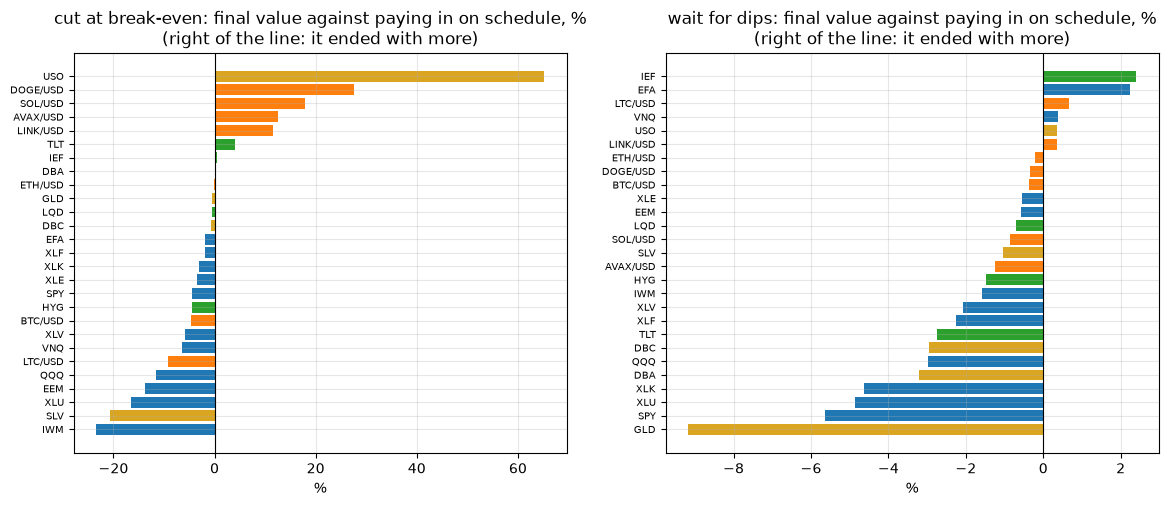

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, name, label in ((left, "cut", "cut at break-even"), (right, "dips", "wait for dips")):
    gain = (paying[f"{name} end"] / paying["schedule end"] - 1) * 100
    order = gain.sort_values().index
    ax.barh(range(len(order)), gain.loc[order], color=[COLOURS[GROUP_OF[s]] for s in order])
    ax.set_yticks(range(len(order)), order, fontsize=7)
    ax.axvline(0, color="black", lw=0.8)
    ax.set(title=f"{label}: final value against paying in on schedule, %\n(right of the line: it ended with more)", xlabel="%")

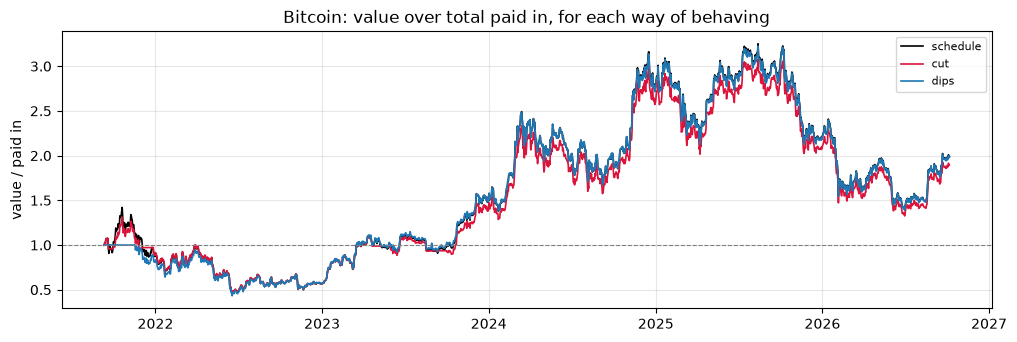

In [8]:
symbol = "BTC/USD"
fig, ax = plt.subplots(figsize=(12, 3.6))
for name, colour in (("schedule", "black"), ("cut", "crimson"), ("dips", "tab:blue")):
    replay = replays[symbol][name]
    ax.plot(replay.index, replay["value"] / replay["paid"], color=colour, lw=1.2, label=name)
ax.axhline(1, color="grey", lw=0.8, ls="--")
ax.set(title="Bitcoin: value over total paid in, for each way of behaving", ylabel="value / paid in")
ax.legend(fontsize=8);

### What part B shows

**Paying in on schedule ended with more than either alternative in about three markets
out of four.** Neither alternative passes.

**Cutting when a gain turns into a loss** is the interesting one, because it does what
it is meant to and still does not pass:

- It ended with *less* than the schedule in 20 of 27 markets. It sells after a fall and
  buys back on a new high, so each round trip costs a little, and in markets that
  mostly rose (the stock funds) those costs add up.
- Its **worst point was better in 21 of 27 markets**. In the markets that crashed
  hardest it was far better and ended with more too: the oil fund's worst point was
  -18% instead of -81%, and it ended at 3.6 times what was paid in instead of 2.2.
- So it is insurance. It costs something in most markets and pays out in a crash. The
  difference at the end is not distinguishable from chance either way (p about 0.10).

**Waiting for dips** ended with less in 21 of 27 markets, and that one is more than
chance. The money waits in cash while prices rise, and the dip it finally buys is
usually above where the schedule had already bought. It did beat leaving the same
amount of cash idle, in 24 of 27, so buying dips is better than holding cash for no
reason; it is just not better than being invested.

**In plain words.** "Sell before the portfolio turns negative" did protect against the
worst outcomes, and the person asking was right that it sometimes misses the turn: that
is exactly what it costs. Over these years, in most markets, continuing to add on
schedule ended with more.

## Part C. Funding rates and buy-side volume

The same question and the same method as notebook 12, on Bitcoin, Ether and Solana from
Binance: **will the close 24 hours from now be higher?** Each model is run twice, once
on price and volume alone and once with the outside data added, so that what the
outside data contributes can be seen directly.

In [9]:
SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT"]
HORIZON, SEEDS = 24, (0, 1, 2)
with binance_public.reader() as source:
    crypto = research.load_binance(SYMBOLS, source, datetime(2020, 1, 1, tzinfo=UTC), datetime(2026, 10, 7, tzinfo=UTC))
for symbol, (frame, funding) in crypto.items():
    print(f"{symbol}: {len(frame)} hourly bars from {frame.index[0].date()}, {len(funding)} funding payments; "
          f"median funding {funding.median() * 100:.4f}% per 8 hours; buy-side share of volume {frame['taker_buy'].sum() / frame['volume'].sum():.1%}")


def prepare(symbol, answers, outside):
    frame, funding = crypto[symbol]
    bar_table, summary_table = direction.bar_inputs(frame), direction.summary_inputs(frame)
    if outside:
        bar_table = pd.concat([bar_table, direction.outside_bars(frame, funding)], axis=1)
        summary_table = pd.concat([summary_table, direction.outside_summary(frame, funding)], axis=1)
    # The same rows for both versions, so they are compared on identical days.
    full_bars = pd.concat([direction.bar_inputs(frame), direction.outside_bars(frame, funding)], axis=1)
    full_summary = pd.concat([direction.summary_inputs(frame), direction.outside_summary(frame, funding)], axis=1)
    usable = direction.usable_rows(full_bars, answers, direction.WINDOW) & full_summary.notna().all(axis=1).to_numpy()
    parts = direction.split(usable, HORIZON)
    return {"parts": parts, "bars": direction.scaled(bar_table, parts.train), "summary": direction.scaled(summary_table, parts.train), "y": answers.to_numpy(dtype=float)}


def run_models(data):
    parts, y = data["parts"], data["y"]
    x_train, x_val, x_test = (direction.windows(data["bars"], rows) for rows in (parts.train, parts.validation, parts.test))
    lstm = np.mean([direction.fit_lstm(x_train, y[parts.train], x_val, y[parts.validation], seed=seed)(x_test) for seed in SEEDS], axis=0)
    summary = data["summary"]
    return {"LSTM": lstm, "small trees": ta.fit_trees(summary[parts.train], y[parts.train])(summary[parts.test]),
            "logistic": direction.fit_logistic(summary[parts.train], y[parts.train])(summary[parts.test])}


def scores(data, chances):
    parts, y = data["parts"], data["y"]
    usual = float(y[parts.train].mean() >= 0.5)
    return {name: direction.score(chance, y[parts.test], usual, HORIZON) for name, chance in chances.items()}


rows = []
for symbol in SYMBOLS:
    recent = direction.summary_inputs(crypto[symbol][0])["ret_24"]
    data = prepare(symbol, direction.planted_answers(recent, seed=11), outside=True)
    test = data["parts"].test[::HORIZON]
    rule = float(((recent.to_numpy()[test] > 0) == (data["y"][test] == 1)).mean())
    for name, result in scores(data, run_models(data)).items():
        rows.append({"market": symbol, "model": name, "right %": result.accuracy * 100, "one answer %": result.baseline * 100,
                     "knowing the rule %": rule * 100, "of the possible gain %": direction.gain_recovered(result, rule) * 100})
planted = pd.DataFrame(rows)
planted["can learn here"] = planted["of the possible gain %"] >= 50
print("Planted pattern, with the outside inputs present:")
planted

BTCUSDT: 59272 hourly bars from 2020-01-01, 7413 funding payments; median funding 0.0090% per 8 hours; buy-side share of volume 49.4%
ETHUSDT: 59272 hourly bars from 2020-01-01, 7413 funding payments; median funding 0.0100% per 8 hours; buy-side share of volume 49.7%
SOLUSDT: 53926 hourly bars from 2020-08-11, 6718 funding payments; median funding 0.0084% per 8 hours; buy-side share of volume 49.7%


Planted pattern, with the outside inputs present:


,market,model,right %,one answer %,knowing the rule %,of the possible gain %,can learn here
0,BTCUSDT,LSTM,59.267,52.749,63.544,60.377,True
1,BTCUSDT,small trees,63.544,52.749,63.544,100.000,True
2,BTCUSDT,logistic,60.285,52.749,63.544,69.811,True
3,ETHUSDT,LSTM,59.063,51.527,63.951,60.656,True
4,ETHUSDT,small trees,63.951,51.527,63.951,100.000,True
5,ETHUSDT,logistic,60.896,51.527,63.951,75.410,True
6,SOLUSDT,LSTM,61.521,56.152,62.864,80.000,True
7,SOLUSDT,small trees,63.311,56.152,62.864,106.667,True
8,SOLUSDT,logistic,62.640,56.152,62.864,96.667,True


In [10]:
rows, kept = [], {}
for symbol in SYMBOLS:
    answers = ta.rises(crypto[symbol][0]["close"], HORIZON)
    for outside in (False, True):
        data = prepare(symbol, answers, outside)
        chances = run_models(data)
        kept[(symbol, outside)] = (data, chances)
        for name, result in scores(data, chances).items():
            rows.append({"market": symbol, "model": name, "inputs": "with outside data" if outside else "price only", **result.model_dump()})
results = pd.DataFrame(rows)
with_outside = results[results["inputs"] == "with outside data"].reset_index(drop=True)
surviving = track.survivors([(i, 0, p) for i, p in enumerate(with_outside["p_value"])], direction.SIGNIFICANCE)
with_outside["survives"] = [(i, 0) in surviving for i in range(len(with_outside))]
with_outside["passes"] = [direction.passes(direction.Score(**row[list(direction.Score.model_fields)].to_dict()), row["survives"]) for _, row in with_outside.iterrows()]

compare = []
for symbol in SYMBOLS:
    data = kept[(symbol, True)][0]
    y = data["y"][data["parts"].test][::HORIZON]
    for name in ("LSTM", "small trees", "logistic"):
        price = (kept[(symbol, False)][1][name][::HORIZON] > 0.5) == (y == 1)
        outside = (kept[(symbol, True)][1][name][::HORIZON] > 0.5) == (y == 1)
        only_outside, only_price = int((outside & ~price).sum()), int((price & ~outside).sum())
        row = with_outside[(with_outside["market"] == symbol) & (with_outside["model"] == name)].iloc[0]
        compare.append({"market": symbol, "model": name, "test days": len(y), "one answer %": row["baseline"] * 100,
                        "price only %": price.mean() * 100, "with outside data %": outside.mean() * 100,
                        "outside adds, points": (outside.mean() - price.mean()) * 100,
                        "days only outside was right": only_outside, "days only price was right": only_price,
                        "p (outside differs)": binomtest(only_outside, only_outside + only_price, 0.5).pvalue if only_outside + only_price else 1.0,
                        "margin over one answer": row["margin"] * 100, "1st half": row["first_half_margin"] * 100, "2nd half": row["second_half_margin"] * 100,
                        "p": row["p_value"], "passes": row["passes"]})
compare = pd.DataFrame(compare)
print(f"Passed the mark of decision 062, with outside data: {int(compare['passes'].sum())} of {len(compare)}")
compare

Passed the mark of decision 062, with outside data: 0 of 9


,market,model,test days,one answer %,price only %,with outside data %,"outside adds, points",days only outside was right,days only price was right,p (outside differs),margin over one answer,1st half,2nd half,p,passes
0,BTCUSDT,LSTM,490,50.000,48.571,48.163,-0.408,87,89,0.940,-1.837,1.224,-4.898,0.805,False
1,BTCUSDT,small trees,490,50.000,51.429,53.469,2.041,74,64,0.444,3.469,6.939,0.000,0.068,False
2,BTCUSDT,logistic,490,50.000,50.408,50.816,0.408,91,89,0.941,0.816,2.041,-0.408,0.376,False
3,ETHUSDT,LSTM,490,49.592,45.714,47.755,2.041,49,39,0.337,-1.837,-2.449,-1.224,0.805,False
4,ETHUSDT,small trees,490,49.592,49.388,46.939,-2.449,48,60,0.290,-2.653,-2.041,-3.265,0.889,False
5,ETHUSDT,logistic,490,49.592,49.592,46.939,-2.653,36,49,0.193,-2.653,-2.041,-3.265,0.889,False
6,SOLUSDT,LSTM,446,49.776,49.327,49.552,0.224,17,16,1.000,-0.224,-0.448,0.000,0.556,False
7,SOLUSDT,small trees,446,49.776,48.430,47.534,-0.897,41,45,0.747,-2.242,-3.139,-1.345,0.840,False
8,SOLUSDT,logistic,446,49.776,45.964,46.413,0.448,43,41,0.913,-3.363,-8.520,1.794,0.929,False


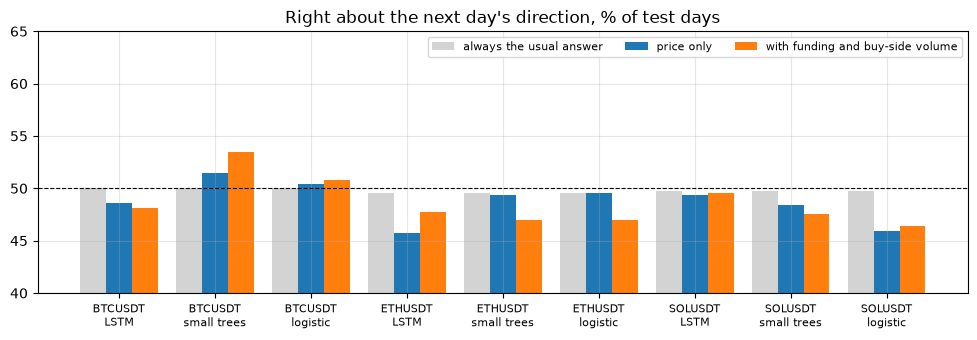

In [11]:
fig, ax = plt.subplots(figsize=(12, 3.4))
x = np.arange(len(compare))
ax.bar(x - 0.27, compare["one answer %"], width=0.27, color="lightgrey", label="always the usual answer")
ax.bar(x, compare["price only %"], width=0.27, color="tab:blue", label="price only")
ax.bar(x + 0.27, compare["with outside data %"], width=0.27, color="tab:orange", label="with funding and buy-side volume")
ax.axhline(50, color="black", lw=0.8, ls="--")
ax.set_xticks(x, [f"{m}\n{k}" for m, k in zip(compare["market"], compare["model"])], fontsize=8)
ax.set(title="Right about the next day's direction, % of test days", ylim=(40, 65))
ax.legend(fontsize=8, ncol=3);

### Crowded funding, as a pattern

When the funding rate is far above its own last 90 days, many traders are paying to
stay long with borrowed money. The common belief is that this comes before a fall. Each
run of crowded payments is counted once.

In [12]:
records = []
for symbol, (frame, funding) in crypto.items():
    z = positioning.unusual(funding, positioning.PAYMENTS)
    close = frame["close"]
    for name, flags in (("crowded long", z >= positioning.CROWDED_FUNDING), ("crowded short", z <= -positioning.CROWDED_FUNDING)):
        starts = pd.DatetimeIndex(positioning.run_starts(flags)).floor("h")
        records.append(track.record("funding", symbol, name, list(starts), close, [(24, "1 day"), (168, "1 week")]))
records = track.correct_family(records)
rows = []
for r in records:
    for h in r.horizons:
        rows.append({"market": r.symbol, "reading": r.variant, "after": h.label, "separate runs": r.n,
                     "rose %": None if h.signal.share_positive is None else h.signal.share_positive * 100,
                     "range low": None if h.signal.share_low is None else h.signal.share_low * 100,
                     "range high": None if h.signal.share_high is None else h.signal.share_high * 100,
                     "any hour %": h.baseline.share_positive * 100, "direction": h.verdict,
                     "typical move %": None if h.signal.mean_size is None else h.signal.mean_size * 100,
                     "any hour move %": h.baseline.mean_size * 100, "size": h.size_verdict})
funding_pattern = pd.DataFrame(rows)
funding_pattern

,market,reading,after,separate runs,rose %,range low,range high,any hour %,direction,typical move %,any hour move %,size
0,BTCUSDT,crowded long,1 day,105,44.762,35.603,54.290,52.343,no measurable edge,2.479,2.080,no measurable difference
1,BTCUSDT,crowded long,1 week,105,55.238,45.710,64.397,54.066,no measurable edge,6.680,5.873,no measurable difference
2,BTCUSDT,crowded short,1 day,137,55.474,47.116,63.534,52.343,no measurable edge,2.127,2.080,no measurable difference
3,BTCUSDT,crowded short,1 week,137,57.463,48.999,65.511,54.066,no measurable edge,5.122,5.873,no measurable difference
4,ETHUSDT,crowded long,1 day,90,50.000,39.884,60.116,52.176,no measurable edge,3.137,2.797,no measurable difference
5,ETHUSDT,crowded long,1 week,90,53.333,43.102,63.292,53.678,no measurable edge,8.214,7.925,no measurable difference
6,ETHUSDT,crowded short,1 day,116,52.586,43.563,61.444,52.176,no measurable edge,3.179,2.797,no measurable difference
7,ETHUSDT,crowded short,1 week,116,53.448,44.406,62.269,53.678,no measurable edge,7.413,7.925,no measurable difference
8,SOLUSDT,crowded long,1 day,60,50.000,37.735,62.265,49.605,no measurable edge,5.051,4.094,no measurable difference
9,SOLUSDT,crowded long,1 week,60,56.667,44.103,68.428,50.688,no measurable edge,12.773,11.398,no measurable difference


### What part C shows

**The models can learn; the outside data did not give them a call on direction.**

- All three models found the planted pattern in all three markets.
- **0 of 9 passed** with funding rates and buy-side volume added.
- The nearest was the small trees on Bitcoin: right on 53.5% of 490 test days against
  50.0%. That clears the 3-point mark, but it is within luck (p about 0.07 before
  allowing for nine comparisons) and all of the advantage came in the first half of the
  test period; in the second half it was level.
- What the outside data added, model by model, ranged from 2.7 points worse to 2.0
  points better. None of those differences is distinguishable from chance.
- **Crowded funding said nothing reliable** about the next day or week, in direction or
  in size, in any of 12 comparisons. For Bitcoin the day after funding became crowded
  long ended higher 45% of the time against 52%, which leans the way the common belief
  says, but with 105 runs the range still covers 52%.

## The result, and my guesses checked

| part | result |
|---|---|
| A. positioning: what followed | not enough runs to judge in any market |
| A. positioning as a sizing rule | did not beat a fixed share anywhere |
| B. cutting at break-even | ended lower in 20 of 27 markets; worst point better in 21 of 27; does not pass |
| B. waiting for dips | ended lower in 21 of 27, more than chance; does not pass |
| C. models with funding and buy-side volume | 0 of 9 passed |
| C. crowded funding as a pattern | nothing measurable in 12 comparisons |

**Guesses (decisions 066 and 067).** Right: too few positioning runs; the sizing rule
not beating its fixed share; neither way of behaving passing; cutting ending lower in
most markets; no model passing. Partly wrong: I said cutting would improve the worst
point "in some" markets, and it did in most. Wrong: I expected crowded funding to be
followed by larger moves, and it was not.

## What this means

After four notebooks the picture is consistent. Nothing tested tells which way a price
goes next: not indicators, not levels, not models on daily or hourly bars, not timing
rules for cash, not positioning, not funding rates, not buy-side volume.

What has held up, each time:

1. **How much is held decides most of the outcome.** A smaller share falls less far and
   earns less, almost in proportion (notebook 13).
2. **How rough the next days will be can be forecast** (notebook 4), even though the
   direction cannot.
3. **Adding on a schedule beat the alternatives in most markets**, and cutting at
   break-even is real insurance with a real price (this notebook).

Those three are what an honest version of "help me resize" can be built from: choose the
share for the fall you can live with; be told when the next week looks rougher than
usual; keep adding on schedule; and, if protection from a crash matters more than the
final figure, a break-even exit shown with what it has cost and saved.

**Limits.** Ten years for funds, five to seven for coins. Part C's nearest miss, small
trees on Bitcoin, is the one result here that a longer record could still turn into a
pass or a clear fail; it is noted, not acted on.